<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [215]:
time_series_df = pd.read_csv('time_series_data.csv')
time_series = time_series_df.iloc[1:] # we drop the July 1998 beacuse the warscore is NaN

print(time_series[:5])

       month  comedypop     score  comscore  horscore  warscore  romscore  \
1  Aug, 1998   0.304348  0.477847  0.508308  0.111763  0.533457  0.683165   
2  Sep, 1998   0.240741  0.474915  0.656311  0.008666  0.769712  0.576273   
3  Oct, 1998   0.185185  0.381850  0.717947  0.026919  0.307859  0.546144   
4  Nov, 1998   0.360000  0.411975  0.623088  0.007610  0.502912  0.609826   
5  Dec, 1998   0.354839  0.393935  0.791300  0.220636  0.131856  0.500945   

   fanscore  9/11  payroll  
1  0.678700     0   126546  
2  0.625900     0   126744  
3  0.611293     0   126949  
4  0.670926     0   127222  
5  0.573754     0   127595  


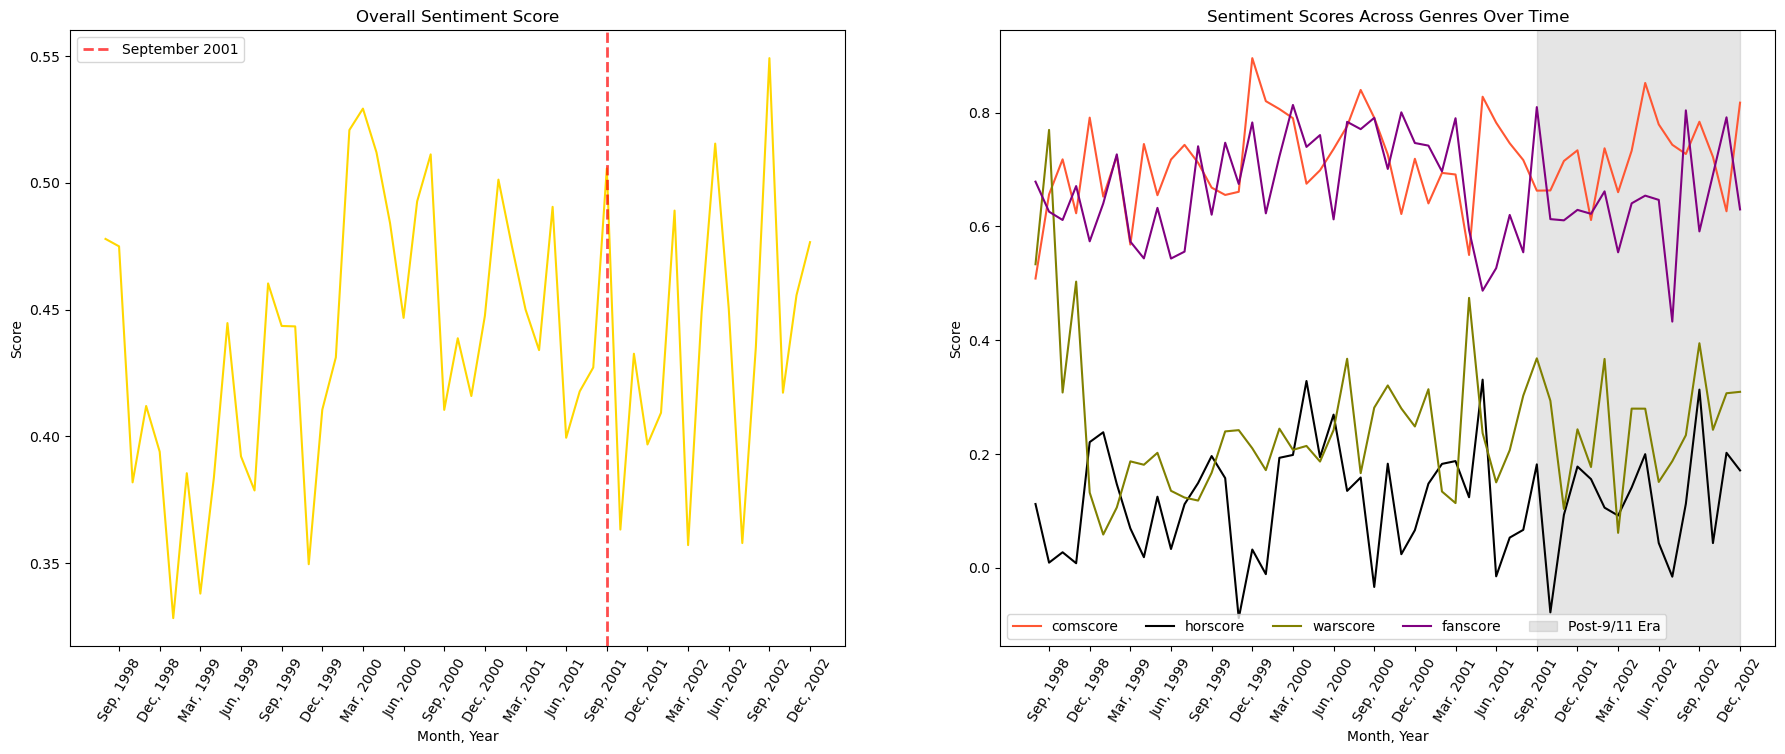

In [216]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

ax1.plot(time_series['month'], time_series['score'], color = 'gold')
ax1.set_title('Overall Sentiment Score')
ax1.set_xlabel('Month, Year')
ax1.set_ylabel('Score')
ax1.set_xticks(time_series['month'][1::3])
ax1.tick_params(axis = 'x', rotation = 60)
ax1.axvline(x = 'Sep, 2001', color = 'red', linestyle = '--', linewidth=2, alpha=0.7, label = 'September 2001')
ax1.legend(loc = 'upper left')

# Second Graph
plot_data = time_series.set_index('month')[['comscore', 'horscore', 'warscore', 'fanscore']]

my_colors = ["#FF5733", "black", "olive", "purple"] # my colors
sns.lineplot(data = plot_data, ax = ax2, dashes = False, palette = my_colors)
ax2.set_title("Sentiment Scores Across Genres Over Time")
ax2.set_xlabel('Month, Year')
ax2.set_ylabel("Score")
plt.xticks(rotation = 60)
ax2.set_xticks(time_series['month'][1::3]) # setting the ticks every three months, starting from the second value

# Shading the area from Sept 11 to the end of your data
# '2002-12-31' is an example end date
ax2.axvspan('Sep, 2001', 'Dec, 2002', color = 'gray', alpha = 0.2, label = 'Post-9/11 Era') # shading
plt.legend(loc = 'lower left', ncol = 5) 

plt.show()

The first graph displays the overall mean sentiment score across all kinds of movies from August 1998 to December 2002, while the second one shows how sentiment for each genre evolves over the same period. Higher scores signify more positive perception, lower scores - more negative. As seen from the left chart, the overall review sentiment sharply dropped following September 2001, after which negativity lingered for a few months. Looking at the genre-specific visualization, all scores fell due to 9/11, with horror- and war-genred reviews reflecting the biggest decline in review sentiment. Interestingly, comedy and romance are regularly perceived more positively than war and horror.

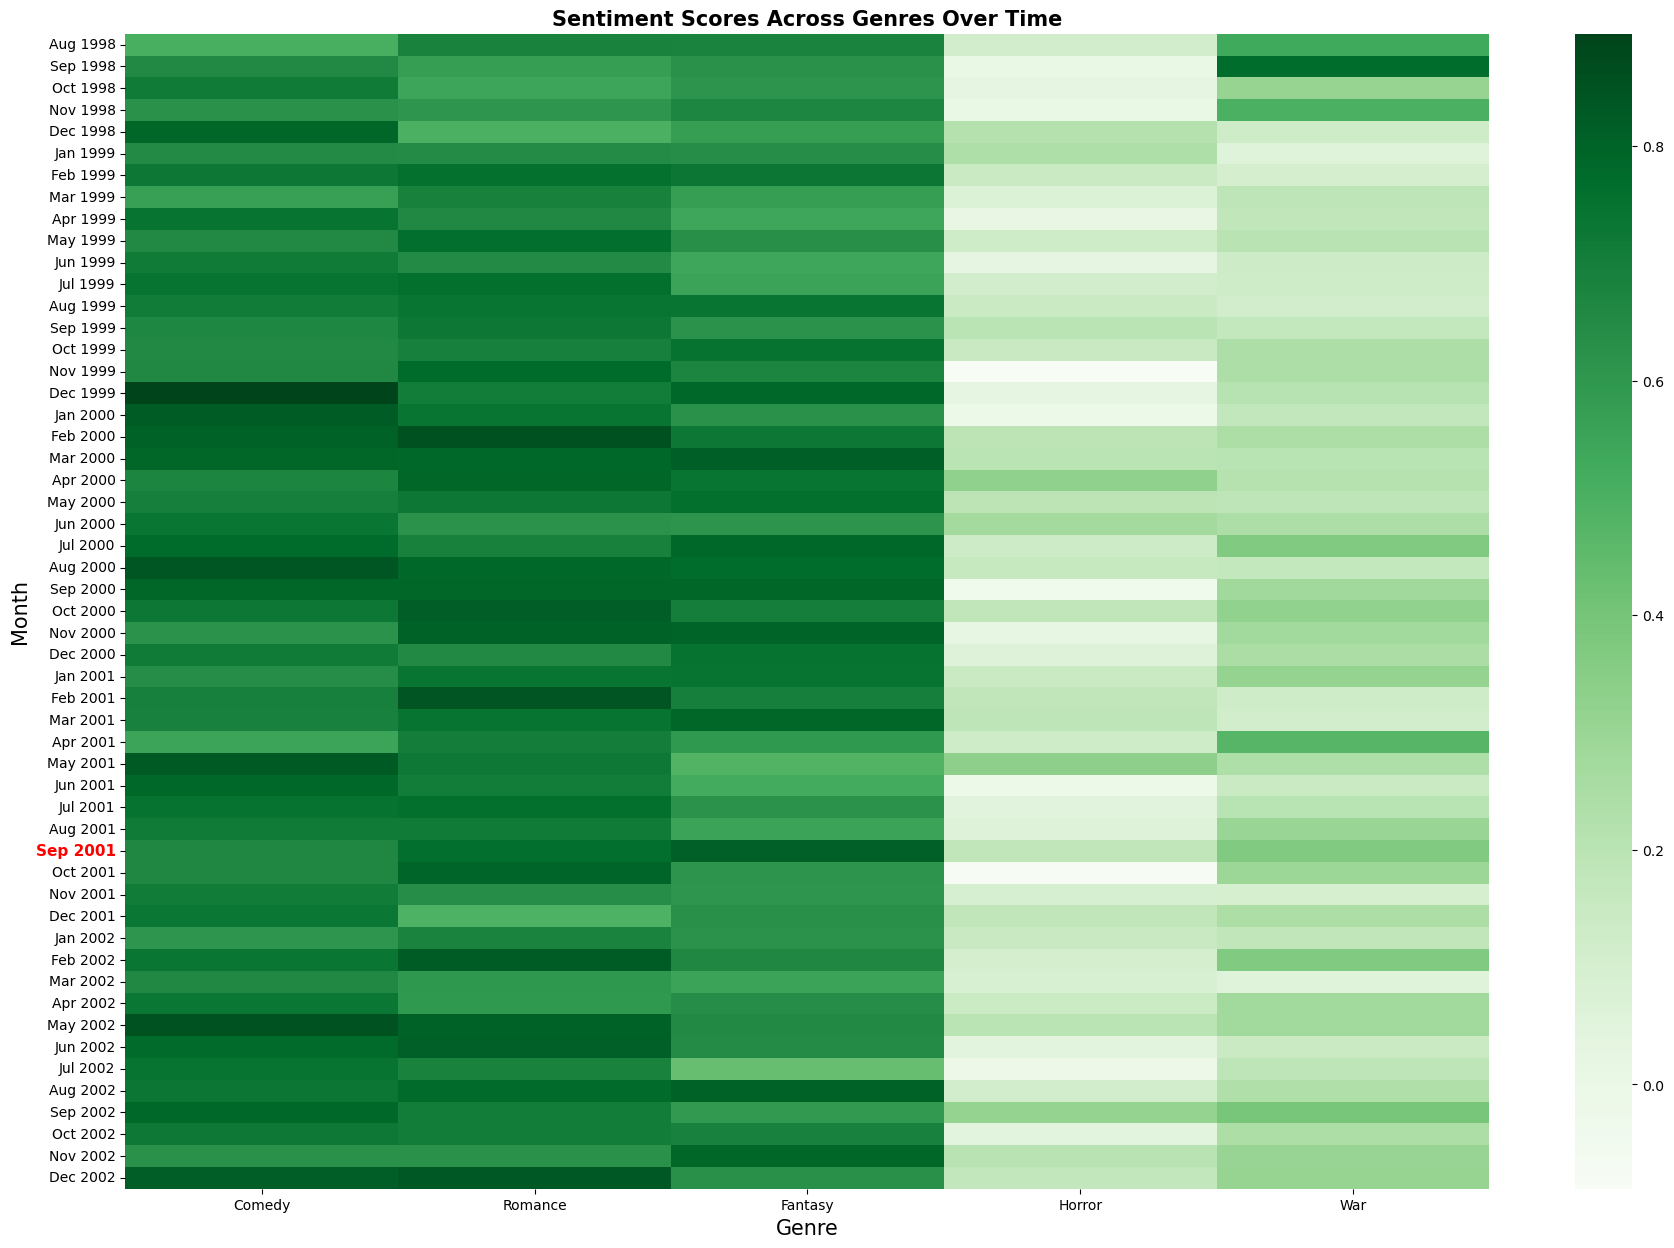

In [214]:
time_series['month'] = pd.to_datetime(time_series['month']) # Convert month to datetime so it sorts correctly
time_series = time_series.sort_values('month') 

# We'll format the date to look cleaner on the axis
plot_df = time_series.set_index(time_series['month'].dt.strftime('%b %Y'))
columns = ['comscore', 'romscore', 'fanscore', 'horscore', 'warscore']

plt.figure(figsize=(22, 15)) # Tall figure for many months 
ax = sns.heatmap(plot_df[columns], cmap = "Greens", annot = False) # - numerical values
ax.set_xticklabels(['Comedy', 'Romance', 'Fantasy', 'Horror', 'War'])
ax.set_ylabel('Month', fontsize = 15)
ax.set_xlabel('Genre', fontsize = 15)

for tick in ax.get_yticklabels():
    if tick.get_text() == "Sep 2001":
        tick.set_color("red")
        tick.set_weight("bold")
        tick.set_fontsize(11)
        
plt.title("Sentiment Scores Across Genres Over Time", weight = 'bold', fontsize = 15)
plt.show()